In [5]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib 
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
print(train.shape,test.shape)
n_train=train.shape[0]

all_features=pd.concat([train.iloc[:,1:-1],test.iloc[:,1:]])
value_features_column=all_features.columns[all_features.dtypes != 'object']
all_features[value_features_column]=all_features[value_features_column]\
    .apply(lambda x: (x-x.mean())/x.std(),axis=0)\
    .fillna(0.)
dummies_features=pd.get_dummies(all_features,dummy_na=True,dtype=float) 
#默认是bool,而混合float和bool会导致格式为 'object'
print(dummies_features.shape)

Id=pd.concat([train["Id"],test["Id"]])
dummies_features=pd.concat([Id,dummies_features],axis=1)

pd_train=pd.concat([dummies_features[:n_train],train.iloc[:,-1]],axis=1)
pd_test=dummies_features[n_train:]

(1460, 81) (1459, 80)
(2919, 330)


In [8]:
pd_train.head(),pd_train.shape

(   Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
 0   1    0.067320    -0.184443 -0.217841     0.646073    -0.507197   1.046078   
 1   2   -0.873466     0.458096 -0.072032    -0.063174     2.187904   0.154737   
 2   3    0.067320    -0.055935  0.137173     0.646073    -0.507197   0.980053   
 3   4    0.302516    -0.398622 -0.078371     0.646073    -0.507197  -1.859033   
 4   5    0.067320     0.629439  0.518814     1.355319    -0.507197   0.947040   
 
    YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_WD  SaleType_nan  \
 0      0.896679    0.523038    0.580708  ...          1.0           0.0   
 1     -0.395536   -0.569893    1.177709  ...          1.0           0.0   
 2      0.848819    0.333448    0.097840  ...          1.0           0.0   
 3     -0.682695   -0.569893   -0.494771  ...          1.0           0.0   
 4      0.753100    1.381770    0.468770  ...          1.0           0.0   
 
    SaleCondition_Abnorml  SaleCondition_AdjLand

```python
n_train=train.shape[0]
train_features=torch.tensor(dummies_features[:n_train].values,dtype=torch.float32)
train_labels=torch.tensor(train.iloc[:,-1].values.reshape(-1,1),dtype=torch.float32) #注意:这里标签是二维的
test_features=torch.tensor(dummies_features[n_train:].values,dtype=torch.float32)
```

In [9]:
class Nets(nn.Module):
    def __init__(self,net,lr,epoch=None):
        super().__init__()
        self.train_features=None
        self.train_labels=None
        self.test_features=None
        self.test_labels=None
        self.net=net
        self.lr=lr
        self.epoch=epoch
    def forward(self,X):
        return self.net(X)

In [28]:
def get_net_1(in_features):
    net=nn.Sequential(nn.Linear(in_features,1))
    return net
#num_epochs, lr, weight_decay, batch_size =250, 6, 5e-3, 64

In [29]:
def get_net_2(in_features):
    net=nn.Sequential(nn.Linear(in_features,64),
                      nn.ReLU(),
                      nn.Dropout(0.5),
                      nn.Linear(64,1))
    return net
#num_epochs, lr, weight_decay, batch_size = 100, 0.1, 1e-3, 64

```python
#测试时写的
net1=Nets(get_net_1())
net2=Nets(get_net_1())
net3=Nets(get_net_2())
three_nets=[net1,net2,net3]
```

In [12]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier))<test_ratio*2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids=data[id_column]
    in_test_set=ids.apply(lambda id_: is_id_in_test_set(id_,test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [13]:
def init_nets(three_nets, pd_train):
    rng=np.random.default_rng(42)
    
    for net in three_nets:
        sample=pd_train.sample(frac=1,replace=True,random_state=rng)
        split_train, split_test=split_data_with_id_hash(sample, 0.2, "Id")
        # Id为唯一标识符
        
        net.train_features=torch.tensor(split_train.iloc[:,1:-1].values,dtype=torch.float32)
        net.train_labels=torch.tensor(split_train.iloc[:,-1].values.reshape(-1,1),dtype=torch.float32)
        net.test_features=torch.tensor(split_test.iloc[:,1:-1].values,dtype=torch.float32)
        net.test_labels=torch.tensor(split_test.iloc[:,-1].values.reshape(-1,1),dtype=torch.float32)

----
train

In [65]:
def log_rmse(net, loss, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

In [17]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator.
    data_arrays: pytorch data, must have dimension 
    batch_size: the size of feature in each iter 
    is_train: shuffle or not
    """
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [18]:
def train_model(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls,test_ls=[],[]
    train_iter=load_array((train_features,train_labels), batch_size,is_train=True)

    optimizer=torch.optim.Adam(net.parameters(),
                               lr=learning_rate,
                               weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X,y in train_iter:
            optimizer.zero_grad()
            l=loss(net(X),y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net,loss,train_features,train_labels))  #log_rmse不是用于训练的
        if test_labels is not None:
            test_ls.append(log_rmse(net,loss,test_features,test_labels))
    return train_ls,test_ls

In [46]:
def train_three(three_nets, num_epochs, weight_decay, batch_size,):
    i=0
    fig, axes = plt.subplots(1, 3,figsize=(9,3))
    for Net in three_nets:
        net=Net.net
        if Net.epoch:
            num_epochs=Net.epoch
        train_ls, valid_ls = train_model(net, Net.train_features, Net.train_labels,
                                   Net.test_features, Net.test_labels, 
                                   num_epochs, Net.lr,
                                   weight_decay, batch_size)
        
        d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                    xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                    legend=['train', 'valid'], yscale='log',
                    axes=axes[i],)
        i+=1
        print(f'网络{i }，训练 log rmse: {float(train_ls[-1]):f}, '
              f'验证 log rmse: {float(valid_ls[-1]):f}')

In [41]:
loss=nn.MSELoss()
in_features=pd_train.shape[1]-2 #一个ID,一个房价y

In [42]:
lr1, lr2=6, 0.1
net1=Nets(get_net_1(in_features),lr1)
net2=Nets(get_net_1(in_features),lr1)
net3=Nets(get_net_2(in_features),lr2,20)
three_nets=[net1,net2,net3]
init_nets(three_nets,pd_train)

In [43]:
net1.train_features.shape,net1.train_labels.shape

(torch.Size([1156, 330]), torch.Size([1156, 1]))

网络1，训练 log rmse: 0.164070, 验证 log rmse: 0.160442
网络2，训练 log rmse: 0.154204, 验证 log rmse: 0.174448
网络3，训练 log rmse: 0.216385, 验证 log rmse: 0.215341


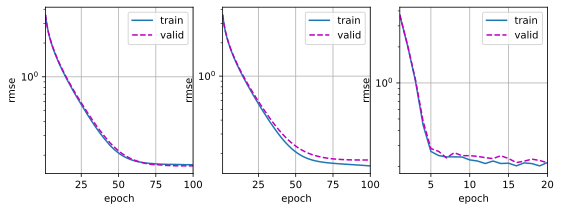

In [44]:
num_epochs, weight_decay, batch_size = 100, 1e-2, 64
train_three(three_nets, num_epochs,weight_decay, batch_size)

[注]:准备工作完成了;之前的数据处理工作真差劲...en,现在也没有修改/进行数据分析*

In [126]:
import math

In [95]:
original=torch.tensor(pd_train.iloc[:,:-1].values,dtype=torch.float32)
unlabeled=torch.tensor(pd_test.values,dtype=torch.float32)
#带了ID

In [55]:
original.shape,unlabeled.shape

(torch.Size([1460, 330]), torch.Size([1459, 330]))

In [119]:
for net_i in three_nets:
    net_i.e_pre=0.5
    net_i.l=0

In [ ]:
for i in range(3):
    net_i=three_nets[i]
    net_j=three_nets[(i+1)%3]
    net_k=three_nets[(i+2)%3]
    #net_i.train=
    net_i.update=False
    net_i.e=MeasureError(net_j,net_k)
    if net_i.e<net_i.e_pre:
        rmse=equal(net_j,net_k,unlabeled[:,1:])
        mask=(rmse<0.05).reshape(-1)
        net_i.train_=torch.concat(net_i.train_,unlabeled[mask])
    
    if net_i.l==0:
        net_i.l=net_i.e/(net_i.e_pre-net_i.e)+1
    if net_i.l<net_i.train_.shape[0]:
        if net_i.e*net_i.train_.shape[0]<net_i.e_pre*net_i.l:
            net_i.update=True
        elif net_i.l>net_i.e/(net_i.e_pre-net_i.e):
            s=math.ceil(net_i.e_pre*net_i.l/net_i.e-1)
            net_i.train_=Subsample(net_i.train_,s) #留下s个样本
            net.update=True



In [131]:
def equal(net_j: Nets, 
          net_k: Nets, 
          unlabeled: torch.Tensor
         ) -> torch.Tensor:
    loss_none=nn.MSELoss(reduction='none')
    
    clipped_preds_j = torch.clamp(net_j(unlabeled), 0.01, float('inf'))
    clipped_preds_k = torch.clamp(net_k(unlabeled), 0.01, float('inf'))
    rmse = torch.sqrt(loss_none(torch.log(clipped_preds_j),
                                torch.log(clipped_preds_k)))
    
    return rmse

In [ ]:
def MeasureError(net_j,net_k) -> float:
    pass

!!  
需要写一个MeasureError和Subsample,  
需要处理样本的放置, 即留下的那个net_i.train_